In [2]:
import pandas as pd

In [3]:
import os
os.listdir()

['.ipynb_checkpoints',
 'healthcare_cleaned_data.xlsx',
 'Hospital_Operations_Python.ipynb']

In [5]:
pd.ExcelFile("healthcare_cleaned_data.xlsx").sheet_names

['Raw_data',
 'Cleaned_Data',
 'Audit_report',
 'Data Summary',
 'Insurance provider distribution',
 'Medical_condition',
 'Admission_Type',
 'Billing by insurance provider',
 'Average length of stay by medic',
 'Test result distribution',
 'overall_quality_status',
 'Dashboard']

In [8]:
df = pd.read_excel(
    "healthcare_cleaned_data.xlsx",
    sheet_name="Cleaned_Data"
)

df.head()

,Name,Age,Gender,Blood _Type,Medical_ Condition,Admission_Date,Doctor,Hospital,Insurance_Provider,Billing _Amount,...,Medication,Test_Results,Age_check,Billing _check,Room_check,Date_check,Missing_data_check,Category_check,Length_of_stay,Overall _quality _status
0,Ronald Davis,13,Male,A+,Obesity,2023-12-06,Shannon Butler,"Kelly, and Gomez Williams",Cigna,3014.565852,...,Paracetamol,Normal,Pass,Pass,Pass,Pass,Pass,Pass,29,Pass
1,Charles Jordan,13,Male,A+,Arthritis,2021-05-13,Brian Baker,"Arellano and Armstrong Hensley,",UnitedHealthcare,10597.383799,...,Penicillin,Normal,Pass,Pass,Pass,Pass,Pass,Pass,30,Pass
2,Dorothy Hoffman,13,Female,O-,Cancer,2020-07-18,Suzanne Jones,"Davis Davis, and Davis",Cigna,22316.169323,...,Ibuprofen,Abnormal,Pass,Pass,Pass,Pass,Pass,Pass,23,Pass
3,James Bass Phd,13,Male,O+,Asthma,2020-12-30,Jennifer Hammond,"Pollard Wallace, Sims and",Blue Cross,22901.022707,...,Ibuprofen,Inconclusive,Pass,Pass,Pass,Pass,Pass,Pass,18,Pass
4,Deanna Palmer,13,Male,AB-,Obesity,2020-09-20,Barbara Butler,"and Sanchez Phillips, Brown",Medicare,23941.759486,...,Penicillin,Inconclusive,Pass,Pass,Pass,Pass,Pass,Pass,3,Pass


In [9]:
df.shape

(54966, 23)

In [10]:
df.columns.tolist()

['Name',
 'Age',
 'Gender',
 'Blood _Type',
 'Medical_ Condition',
 'Admission_Date',
 'Doctor',
 'Hospital',
 'Insurance_Provider',
 'Billing _Amount',
 'Room _Number',
 'Admission_Type',
 'Discharge_Date',
 'Medication',
 'Test_Results',
 'Age_check',
 'Billing _check',
 'Room_check',
 'Date_check ',
 'Missing_data_check',
 'Category_check ',
 'Length_of_stay',
 'Overall _quality _status']

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Name                      54966 non-null  str           
 1   Age                       54966 non-null  int64         
 2   Gender                    54966 non-null  str           
 3   Blood _Type               54966 non-null  str           
 4   Medical_ Condition        54966 non-null  str           
 5   Admission_Date            54966 non-null  datetime64[us]
 6   Doctor                    54966 non-null  str           
 7   Hospital                  54966 non-null  str           
 8   Insurance_Provider        54966 non-null  str           
 9   Billing _Amount           54966 non-null  float64       
 10  Room _Number              54966 non-null  int64         
 11  Admission_Type            54966 non-null  str           
 12  Discharge_Date            549

In [12]:
df.isnull().sum()

Name                        0
Age                         0
Gender                      0
Blood _Type                 0
Medical_ Condition          0
Admission_Date              0
Doctor                      0
Hospital                    0
Insurance_Provider          0
Billing _Amount             0
Room _Number                0
Admission_Type              0
Discharge_Date              0
Medication                  0
Test_Results                0
Age_check                   0
Billing _check              0
Room_check                  0
Date_check                  0
Missing_data_check          0
Category_check              0
Length_of_stay              0
Overall _quality _status    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
)

df.columns.tolist()

['name',
 'age',
 'gender',
 'blood_type',
 'medical_condition',
 'admission_date',
 'doctor',
 'hospital',
 'insurance_provider',
 'billing_amount',
 'room_number',
 'admission_type',
 'discharge_date',
 'medication',
 'test_results',
 'age_check',
 'billing_check',
 'room_check',
 'date_check',
 'missing_data_check',
 'category_check',
 'length_of_stay',
 'overall_quality_status']

In [15]:
df[["age", "billing_amount", "length_of_stay"]].describe().round(2)

,age,billing_amount,length_of_stay
count,54966.00,54966.00,54966.00
mean,51.54,25544.31,15.50
std,19.61,14208.41,8.66
min,13.00,-2008.49,1.00
25%,35.00,13243.72,8.00
50%,52.00,25542.75,15.00
75%,68.00,37819.86,23.00
max,89.00,52764.28,30.00


In [16]:
(df["billing_amount"] < 0).sum()

np.int64(106)

In [17]:
valid_billing_df = df[df["billing_amount"] >= 0].copy()

valid_billing_df.shape

(54860, 23)

In [18]:
valid_billing_rate = (
    len(valid_billing_df) / len(df)
) * 100

round(valid_billing_rate, 2)

99.81

In [19]:
condition_counts = (
    df["medical_condition"]
    .value_counts()
    .reset_index()
)

condition_counts.columns = ["medical_condition", "admissions"]

condition_counts

,medical_condition,admissions
0,Arthritis,9218
1,Diabetes,9216
2,Hypertension,9151
3,Obesity,9146
4,Cancer,9140
5,Asthma,9095


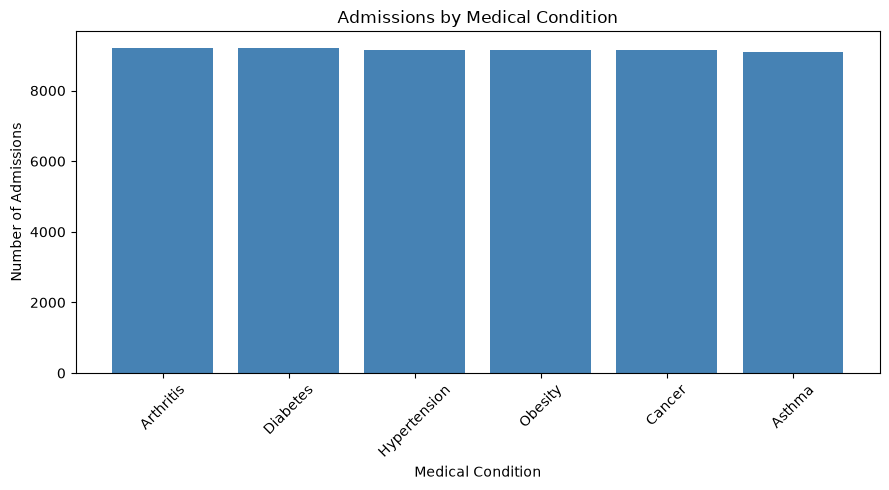

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    condition_counts["medical_condition"],
    condition_counts["admissions"],
    color="steelblue"
)

plt.title("Admissions by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
avg_stay_by_condition = (
    df.groupby("medical_condition")["length_of_stay"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)

avg_stay_by_condition.columns = [
    "medical_condition",
    "average_length_of_stay"
]

avg_stay_by_condition

,medical_condition,average_length_of_stay
0,Asthma,15.68
1,Arthritis,15.50
2,Cancer,15.50
3,Obesity,15.45
4,Hypertension,15.44
5,Diabetes,15.43


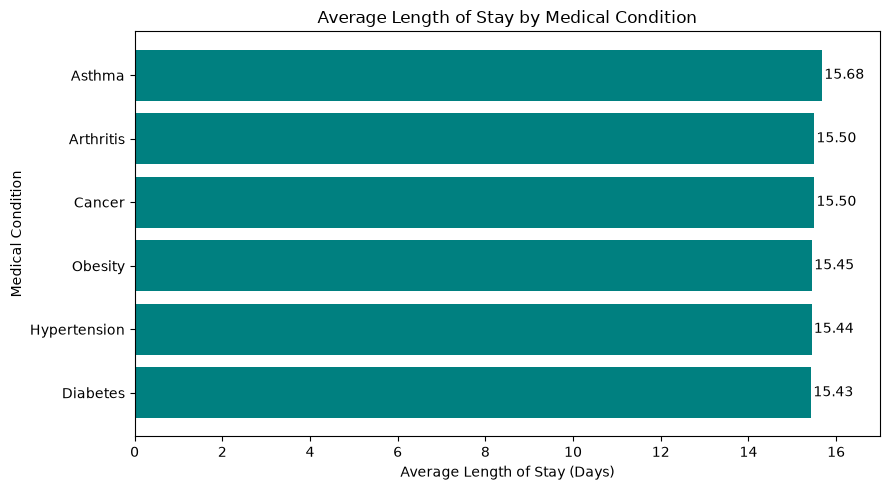

In [22]:
plt.figure(figsize=(9, 5))

bars = plt.barh(
    avg_stay_by_condition["medical_condition"],
    avg_stay_by_condition["average_length_of_stay"],
    color="teal"
)

plt.title("Average Length of Stay by Medical Condition")
plt.xlabel("Average Length of Stay (Days)")
plt.ylabel("Medical Condition")
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}",
        va="center"
    )

plt.xlim(0, 17)
plt.tight_layout()
plt.show()

In [23]:
avg_billing_by_condition = (
    valid_billing_df
    .groupby("medical_condition")["billing_amount"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)

avg_billing_by_condition.columns = [
    "medical_condition",
    "average_valid_billing"
]

avg_billing_by_condition

,medical_condition,average_valid_billing
0,Obesity,25859.22
1,Diabetes,25714.33
2,Asthma,25685.39
3,Hypertension,25559.84
4,Arthritis,25542.90
5,Cancer,25205.92


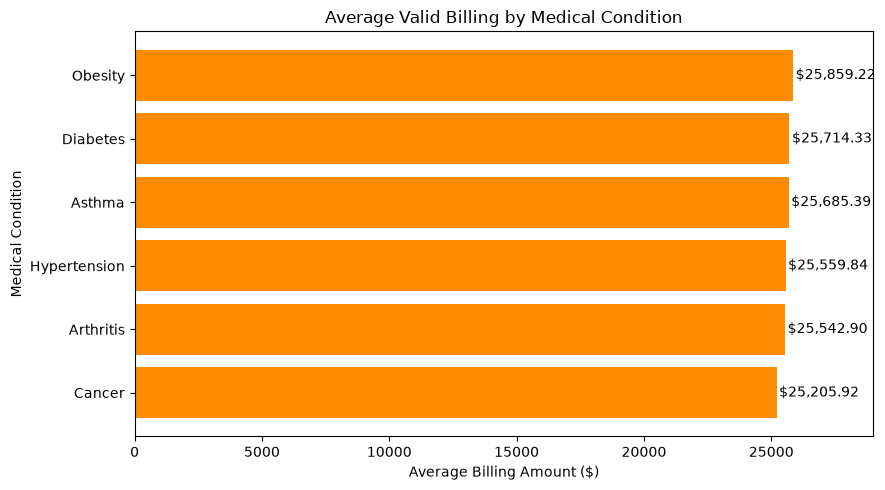

In [24]:
plt.figure(figsize=(9, 5))

bars = plt.barh(
    avg_billing_by_condition["medical_condition"],
    avg_billing_by_condition["average_valid_billing"],
    color="darkorange"
)

plt.title("Average Valid Billing by Medical Condition")
plt.xlabel("Average Billing Amount ($)")
plt.ylabel("Medical Condition")
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.2f}",
        va="center"
    )

plt.xlim(0, 29000)
plt.tight_layout()
plt.show()

In [25]:
admission_summary = (
    df["admission_type"]
    .value_counts()
    .reset_index()
)

admission_summary.columns = [
    "admission_type",
    "admissions"
]

admission_summary["percentage"] = (
    admission_summary["admissions"] / len(df) * 100
).round(2)

admission_summary

,admission_type,admissions,percentage
0,Elective,18473,33.61
1,Urgent,18391,33.46
2,Emergency,18102,32.93


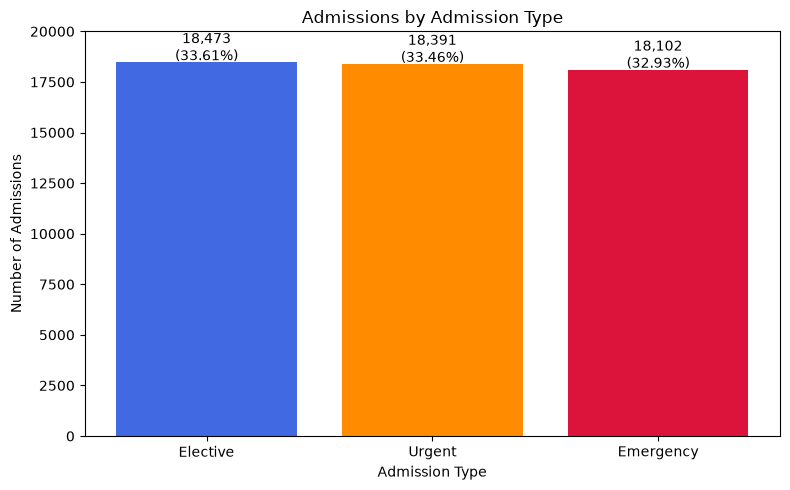

In [26]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    admission_summary["admission_type"],
    admission_summary["admissions"],
    color=["royalblue", "darkorange", "crimson"]
)

plt.title("Admissions by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Admissions")

for bar, percentage in zip(
    bars,
    admission_summary["percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{int(bar.get_height()):,}\n({percentage:.2f}%)",
        ha="center"
    )

plt.ylim(0, 20000)
plt.tight_layout()
plt.show()

In [27]:
df["admission_month"] = (
    df["admission_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_admissions = (
    df.groupby("admission_month")
    .size()
    .reset_index(name="admissions")
)

monthly_admissions.head()

,admission_month,admissions
0,2019-05,677
1,2019-06,899
2,2019-07,951
3,2019-08,985
4,2019-09,924


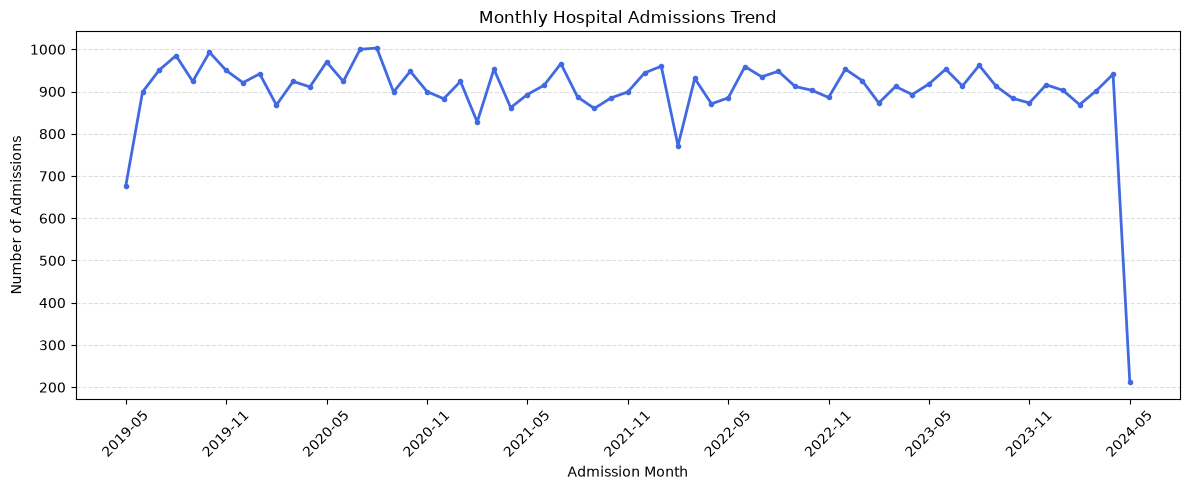

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_admissions["admission_month"],
    monthly_admissions["admissions"],
    color="royalblue",
    marker="o",
    markersize=3,
    linewidth=2
)

plt.title("Monthly Hospital Admissions Trend")
plt.xlabel("Admission Month")
plt.ylabel("Number of Admissions")

plt.xticks(
    range(0, len(monthly_admissions), 6),
    monthly_admissions["admission_month"][::6],
    rotation=45
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [29]:
df["admission_date"].agg(["min", "max"])

min   2019-05-08
max   2024-05-07
Name: admission_date, dtype: datetime64[us]

In [30]:
complete_months = monthly_admissions[
    (monthly_admissions["admission_month"] >= "2019-06") &
    (monthly_admissions["admission_month"] <= "2024-04")
].copy()

complete_months.iloc[[0, -1]]

,admission_month,admissions
1,2019-06,899
59,2024-04,941


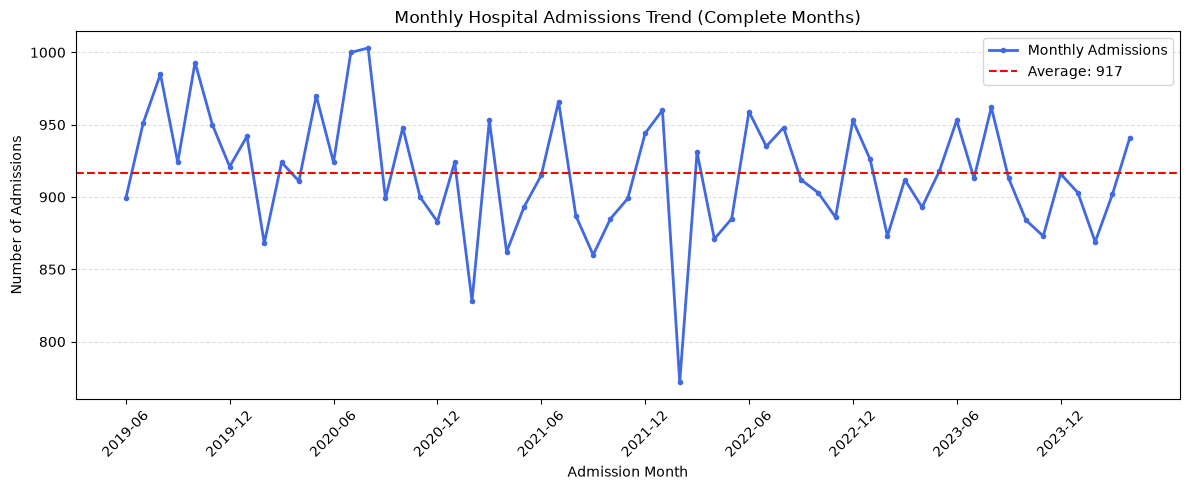

In [31]:
average_monthly_admissions = complete_months["admissions"].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    complete_months["admission_month"],
    complete_months["admissions"],
    color="royalblue",
    marker="o",
    markersize=3,
    linewidth=2,
    label="Monthly Admissions"
)

plt.axhline(
    average_monthly_admissions,
    color="red",
    linestyle="--",
    label=f"Average: {average_monthly_admissions:.0f}"
)

plt.title("Monthly Hospital Admissions Trend (Complete Months)")
plt.xlabel("Admission Month")
plt.ylabel("Number of Admissions")

plt.xticks(
    range(0, len(complete_months), 6),
    complete_months["admission_month"][::6],
    rotation=45
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
highest_month = complete_months.loc[
    complete_months["admissions"].idxmax()
]

lowest_month = complete_months.loc[
    complete_months["admissions"].idxmin()
]

monthly_extremes = pd.DataFrame({
    "category": ["Highest Admissions", "Lowest Admissions"],
    "month": [
        highest_month["admission_month"],
        lowest_month["admission_month"]
    ],
    "admissions": [
        highest_month["admissions"],
        lowest_month["admissions"]
    ]
})

monthly_extremes

,category,month,admissions
0,Highest Admissions,2020-08,1003
1,Lowest Admissions,2022-02,772


In [33]:
complete_months["days_in_month"] = pd.PeriodIndex(
    complete_months["admission_month"],
    freq="M"
).days_in_month

complete_months["admissions_per_day"] = (
    complete_months["admissions"]
    / complete_months["days_in_month"]
).round(2)

complete_months[
    [
        "admission_month",
        "admissions",
        "days_in_month",
        "admissions_per_day"
    ]
].head()

,admission_month,admissions,days_in_month,admissions_per_day
1,2019-06,899,30,29.97
2,2019-07,951,31,30.68
3,2019-08,985,31,31.77
4,2019-09,924,30,30.80
5,2019-10,993,31,32.03


In [34]:
highest_daily = complete_months.loc[
    complete_months["admissions_per_day"].idxmax()
]

lowest_daily = complete_months.loc[
    complete_months["admissions_per_day"].idxmin()
]

daily_extremes = pd.DataFrame({
    "category": ["Highest Daily Rate", "Lowest Daily Rate"],
    "month": [
        highest_daily["admission_month"],
        lowest_daily["admission_month"]
    ],
    "admissions_per_day": [
        highest_daily["admissions_per_day"],
        lowest_daily["admissions_per_day"]
    ]
})

daily_extremes

,category,month,admissions_per_day
0,Highest Daily Rate,2020-08,32.35
1,Lowest Daily Rate,2022-02,27.57


In [35]:
insurance_summary = (
    df["insurance_provider"]
    .value_counts()
    .reset_index()
)

insurance_summary.columns = [
    "insurance_provider",
    "admissions"
]

insurance_summary["percentage"] = (
    insurance_summary["admissions"] / len(df) * 100
).round(2)

insurance_summary

,insurance_provider,admissions,percentage
0,Cigna,11139,20.27
1,Medicare,11039,20.08
2,UnitedHealthcare,11014,20.04
3,Blue Cross,10952,19.93
4,Aetna,10822,19.69


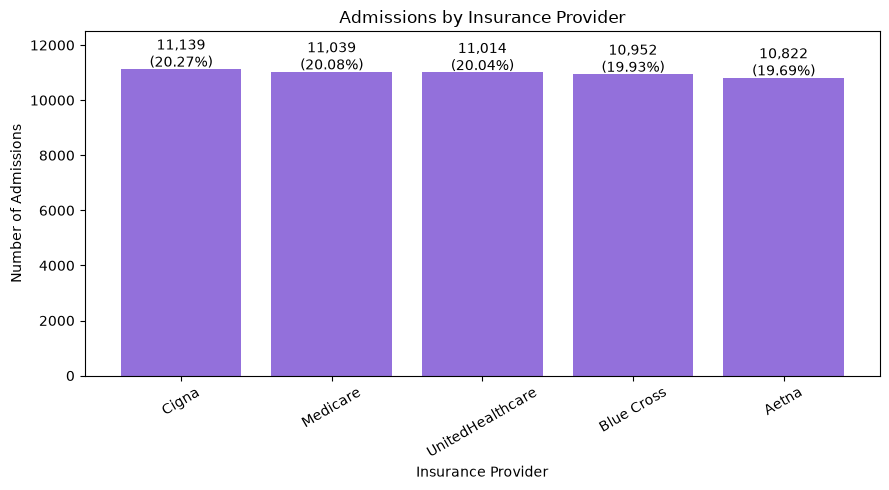

In [36]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    insurance_summary["insurance_provider"],
    insurance_summary["admissions"],
    color="mediumpurple"
)

plt.title("Admissions by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=30)

for bar, percentage in zip(
    bars,
    insurance_summary["percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{int(bar.get_height()):,}\n({percentage:.2f}%)",
        ha="center"
    )

plt.ylim(0, 12500)
plt.tight_layout()
plt.show()

In [37]:
insurance_billing = (
    valid_billing_df
    .groupby("insurance_provider")["billing_amount"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)

insurance_billing.columns = [
    "insurance_provider",
    "average_valid_billing"
]

insurance_billing

,insurance_provider,average_valid_billing
0,Medicare,25678.09
1,Blue Cross,25639.27
2,Aetna,25615.26
3,Cigna,25582.23
4,UnitedHealthcare,25458.89


In [38]:
top_hospitals = (
    df["hospital"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_hospitals.columns = [
    "hospital",
    "admissions"
]

top_hospitals

,hospital,admissions
0,LLC Smith,44
1,Ltd Smith,39
2,Johnson PLC,37
3,Smith Ltd,37
4,Smith Group,36
5,Smith PLC,36
6,Johnson Inc,34
7,Smith Inc,33
8,Group Smith,32
9,Smith LLC,32


In [39]:
unique_hospitals = df["hospital"].nunique()

top_10_share = (
    top_hospitals["admissions"].sum() / len(df) * 100
)

print("Unique hospitals:", unique_hospitals)
print("Top 10 share of admissions:", round(top_10_share, 2), "%")

Unique hospitals: 39876
Top 10 share of admissions: 0.65 %


In [40]:
quality_summary = (
    df["overall_quality_status"]
    .value_counts()
    .reset_index()
)

quality_summary.columns = [
    "quality_status",
    "records"
]

quality_summary["percentage"] = (
    quality_summary["records"] / len(df) * 100
).round(2)

quality_summary

,quality_status,records,percentage
0,Pass,54860,99.81
1,Warning,106,0.19


In [42]:
pd.crosstab(
    df["overall_quality_status"],
    df["billing_check"]
)

billing_check,Pass,Review
overall_quality_status,,
Pass,54860,0
Warning,0,106


In [43]:
age_bins = [0, 17, 34, 49, 64, 120]

age_labels = [
    "Under 18",
    "18–34",
    "35–49",
    "50–64",
    "65+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)

age_group_summary = (
    df["age_group"]
    .value_counts(sort=False)
    .reset_index()
)

age_group_summary.columns = [
    "age_group",
    "patients"
]

age_group_summary

,age_group,patients
0,Under 18,116
1,18–34,13485
2,35–49,12154
3,50–64,12288
4,65+,16923


In [44]:
age_group_summary["percentage"] = (
    age_group_summary["patients"] / len(df) * 100
).round(2)

age_group_summary

,age_group,patients,percentage
0,Under 18,116,0.21
1,18–34,13485,24.53
2,35–49,12154,22.11
3,50–64,12288,22.36
4,65+,16923,30.79


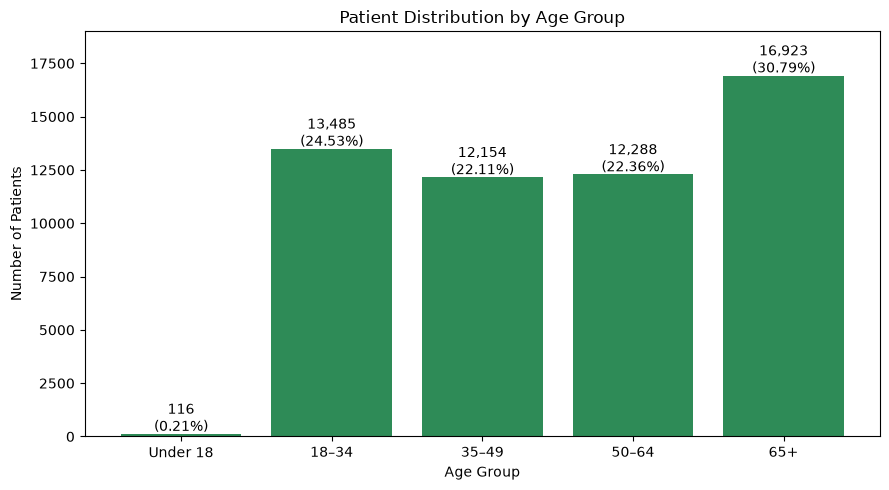

In [45]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    age_group_summary["age_group"].astype(str),
    age_group_summary["patients"],
    color="seagreen"
)

plt.title("Patient Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

for bar, percentage in zip(
    bars,
    age_group_summary["percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f"{int(bar.get_height()):,}\n({percentage:.2f}%)",
        ha="center"
    )

plt.ylim(0, 19000)
plt.tight_layout()
plt.show()

In [46]:
gender_summary = (
    df["gender"]
    .value_counts()
    .reset_index()
)

gender_summary.columns = [
    "gender",
    "patients"
]

gender_summary["percentage"] = (
    gender_summary["patients"] / len(df) * 100
).round(2)

gender_summary

,gender,patients,percentage
0,Male,27496,50.02
1,Female,27470,49.98


In [47]:
test_result_summary = (
    df["test_results"]
    .value_counts()
    .reset_index()
)

test_result_summary.columns = [
    "test_result",
    "patients"
]

test_result_summary["percentage"] = (
    test_result_summary["patients"] / len(df) * 100
).round(2)

test_result_summary

,test_result,patients,percentage
0,Abnormal,18437,33.54
1,Normal,18331,33.35
2,Inconclusive,18198,33.11


In [48]:
correlation_matrix = df[
    ["age", "billing_amount", "length_of_stay"]
].corr().round(3)

correlation_matrix

,age,billing_amount,length_of_stay
age,1.000,-0.003,0.008
billing_amount,-0.003,1.000,-0.005
length_of_stay,0.008,-0.005,1.000


In [49]:
high_cost_threshold = valid_billing_df[
    "billing_amount"
].quantile(0.95)

high_cost_records = valid_billing_df[
    valid_billing_df["billing_amount"] >= high_cost_threshold
].copy()

print(
    "High-cost threshold: $",
    round(high_cost_threshold, 2)
)

print(
    "Number of high-cost records:",
    len(high_cost_records)
)

High-cost threshold: $ 47641.28
Number of high-cost records: 2743


In [50]:
valid_billing_df["high_cost"] = (
    valid_billing_df["billing_amount"]
    >= high_cost_threshold
)

high_cost_by_condition = (
    valid_billing_df
    .groupby("medical_condition")
    .agg(
        total_records=("billing_amount", "size"),
        high_cost_records=("high_cost", "sum")
    )
    .reset_index()
)

high_cost_by_condition["high_cost_rate"] = (
    high_cost_by_condition["high_cost_records"]
    / high_cost_by_condition["total_records"]
    * 100
).round(2)

high_cost_by_condition = (
    high_cost_by_condition
    .sort_values("high_cost_rate", ascending=False)
)

high_cost_by_condition

,medical_condition,total_records,high_cost_records,high_cost_rate
4,Hypertension,9131,474,5.19
1,Asthma,9077,462,5.09
0,Arthritis,9207,465,5.05
5,Obesity,9127,460,5.04
3,Diabetes,9197,463,5.03
2,Cancer,9121,419,4.59


In [51]:
long_stay_threshold = df[
    "length_of_stay"
].quantile(0.75)

df["long_stay"] = (
    df["length_of_stay"] > long_stay_threshold
)

print(
    "Long-stay threshold:",
    long_stay_threshold,
    "days"
)

print(
    "Number of long-stay records:",
    df["long_stay"].sum()
)

Long-stay threshold: 23.0 days
Number of long-stay records: 12780


In [52]:
df["high_cost"] = (
    df["billing_amount"] >= high_cost_threshold
)

df["operational_attention_score"] = (
    (df["admission_type"] == "Emergency").astype(int)
    + (df["test_results"] == "Abnormal").astype(int)
    + df["long_stay"].astype(int)
    + df["high_cost"].astype(int)
)

df["attention_level"] = pd.cut(
    df["operational_attention_score"],
    bins=[-1, 0, 2, 4],
    labels=["Low", "Medium", "High"]
)

df[
    [
        "admission_type",
        "test_results",
        "length_of_stay",
        "billing_amount",
        "operational_attention_score",
        "attention_level"
    ]
].head()

,admission_type,test_results,length_of_stay,billing_amount,operational_attention_score,attention_level
0,Emergency,Normal,29,3014.565852,2,Medium
1,Emergency,Normal,30,10597.383799,2,Medium
2,Elective,Abnormal,23,22316.169323,1,Medium
3,Emergency,Inconclusive,18,22901.022707,1,Medium
4,Emergency,Inconclusive,3,23941.759486,1,Medium


In [53]:
attention_summary = (
    df["attention_level"]
    .value_counts(sort=False)
    .reset_index()
)

attention_summary.columns = [
    "attention_level",
    "records"
]

attention_summary["percentage"] = (
    attention_summary["records"] / len(df) * 100
).round(2)

attention_summary

,attention_level,records,percentage
0,Low,17831,32.44
1,Medium,35227,64.09
2,High,1908,3.47


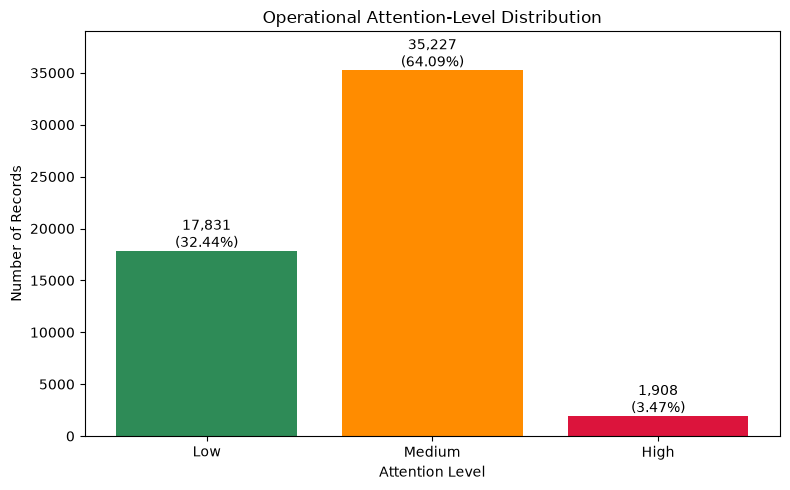

In [54]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    attention_summary["attention_level"].astype(str),
    attention_summary["records"],
    color=["seagreen", "darkorange", "crimson"]
)

plt.title("Operational Attention-Level Distribution")
plt.xlabel("Attention Level")
plt.ylabel("Number of Records")

for bar, percentage in zip(
    bars,
    attention_summary["percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 400,
        f"{int(bar.get_height()):,}\n({percentage:.2f}%)",
        ha="center"
    )

plt.ylim(0, 39000)
plt.tight_layout()
plt.show()


In [55]:
high_attention_records = df.loc[
    df["operational_attention_score"] >= 3,
    [
        "age",
        "age_group",
        "gender",
        "medical_condition",
        "admission_type",
        "admission_date",
        "discharge_date",
        "length_of_stay",
        "insurance_provider",
        "billing_amount",
        "test_results",
        "operational_attention_score",
        "overall_quality_status"
    ]
].copy()

high_attention_records.to_csv(
    "high_attention_records.csv",
    index=False
)

print(
    "Saved records:",
    len(high_attention_records)
)

Saved records: 1908


In [56]:
import sklearn

print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.9.0


In [57]:
model_features = [
    "age",
    "gender",
    "blood_type",
    "medical_condition",
    "admission_type",
    "insurance_provider"
]

X = df[model_features]

y = df["long_stay"].astype(int)

print("Input table shape:", X.shape)
print("Target counts:")
print(y.value_counts())

Input table shape: (54966, 6)
Target counts:
long_stay
0    42186
1    12780
Name: count, dtype: int64


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 43972
Testing records: 10994


In [59]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(
    "Baseline accuracy:",
    round(baseline_accuracy * 100, 2),
    "%"
)

Baseline accuracy: 76.75 %


In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_features = ["age"]

categorical_features = [
    "gender",
    "blood_type",
    "medical_condition",
    "admission_type",
    "insurance_provider"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

long_stay_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

long_stay_model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [61]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

model_predictions = long_stay_model.predict(X_test)

model_accuracy = accuracy_score(
    y_test,
    model_predictions
)

print(
    "Model accuracy:",
    round(model_accuracy * 100, 2),
    "%"
)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        model_predictions,
        target_names=[
            "Not Long Stay",
            "Long Stay"
        ]
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_test,
        model_predictions
    )
)

Model accuracy: 50.58 %

Classification report:
               precision    recall  f1-score   support

Not Long Stay       0.77      0.50      0.61      8438
    Long Stay       0.24      0.52      0.33      2556

     accuracy                           0.51     10994
    macro avg       0.51      0.51      0.47     10994
 weighted avg       0.65      0.51      0.54     10994

Confusion matrix:
[[4237 4201]
 [1232 1324]]


In [62]:
from sklearn.metrics import roc_auc_score

model_probabilities = long_stay_model.predict_proba(
    X_test
)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    model_probabilities
)

print(
    "ROC-AUC:",
    round(roc_auc, 3)
)

ROC-AUC: 0.513


In [65]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

model_comparison = pd.DataFrame({
    "model": [
        "Majority-Class Baseline",
        "Balanced Logistic Regression"
    ],
    "accuracy": [
        accuracy_score(
            y_test,
            baseline_predictions
        ),
        accuracy_score(
            y_test,
            model_predictions
        )
    ],
    "long_stay_precision": [
        precision_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),
        precision_score(
            y_test,
            model_predictions
        )
    ],
    "long_stay_recall": [
        recall_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            model_predictions
        )
    ],
    "long_stay_f1": [
        f1_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            model_predictions
        )
    ],
    "roc_auc": [
        0.50,
        roc_auc
    ]
})

metric_columns = [
    "accuracy",
    "long_stay_precision",
    "long_stay_recall",
    "long_stay_f1",
    "roc_auc"
]

model_comparison[metric_columns] = (
    model_comparison[metric_columns].round(3)
)
model_comparison.to_csv(
    "model_evaluation.csv",
    index=False
)

model_comparison

,model,accuracy,long_stay_precision,long_stay_recall,long_stay_f1,roc_auc
0,Majority-Class Baseline,0.768,0.00,0.000,0.000,0.500
1,Balanced Logistic Regression,0.506,0.24,0.518,0.328,0.513


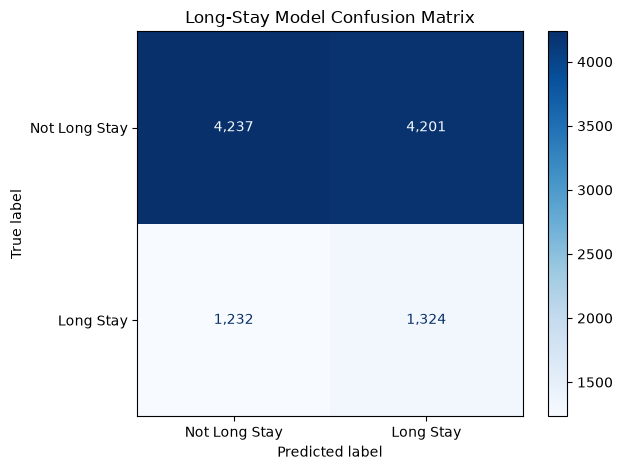

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_predictions,
    display_labels=[
        "Not Long Stay",
        "Long Stay"
    ],
    cmap="Blues",
    values_format=","
)

plt.title("Long-Stay Model Confusion Matrix")
plt.tight_layout()
plt.show()

## Machine-Learning Evaluation

A balanced logistic-regression model was developed to predict long hospital stays using age, gender, blood type, medical condition, admission type, and insurance provider.

The majority-class baseline achieved 76.75% accuracy but identified no long-stay cases. The logistic-regression model achieved 50.58% accuracy, 51.80% long-stay recall, 24.00% precision, and a ROC-AUC of 0.513. These results indicate that the available features contain very little predictive signal.

The model should not be deployed for operational or clinical decision-making. Additional variables—such as diagnosis severity, comorbidities, prior utilization, procedures, staffing levels, and discharge barriers—would be required before developing a reliable long-stay prediction model.


## Executive Findings and Recommendations

- The dataset contains 54,966 admission records with no missing or duplicate rows.
- Billing quality was high: 54,860 records passed validation, while 106 negative billing records were flagged for review.
- Admissions were distributed evenly across medical conditions. Arthritis had the highest volume at 9,218 admissions, while Asthma had the lowest at 9,095.
- Asthma had the longest average stay at 15.68 days, although differences between conditions were small.
- Obesity had the highest average valid billing at $25,859.22, while Cancer had the lowest at $25,205.92.
- Elective, urgent, and emergency admissions each represented approximately one-third of all records.
- Patients aged 65 and older were the largest age group, representing 30.79% of admissions.
- Average monthly volume was approximately 917 admissions after excluding incomplete months. February 2022 had the lowest adjusted daily admission rate.
- Hospital workload analysis was limited by 39,876 unique hospital names. A standardized hospital identifier is required before comparing hospital performance.
- A rule-based operational review identified 1,908 high-attention records. These records should be reviewed operationally and should not be treated as confirmed clinical risk.
- The long-stay prediction model was not reliable. Future analysis should include clinical severity, comorbidities, prior utilization, procedures, staffing and discharge-barrier data.